## Phildelphia Shooter Demographics

![](data/image.png)

Mass shootings in the United States peaked during the pandemic and have steadily declined since. Still, with roughly 40,000 people shot in 2025, levels of gun violence remain well above their pre-2019 baseline.

Given this scale, a natural starting point for me was to examine the demographics of those involved in shootings. Rather than treating gun violence as a uniform phenomenon, breaking it down by race, sex, and age allows for a more precise understanding of who is most affected.

Philadelphia consistently ranks among the cities with the highest total number of shootings, alongside other major metropolitan areas. This pattern has been widely reported, highlighted, for example, in a 2021 CBS News headline during the height of the pandemic surge.

![](data/headline.png)

First I wanted to generally acquaint myself, looking at the data in terms of race, gender, and age. 

In [31]:
shoot_df['race'].value_counts()

race
B    14198
W     3011
A      121
U       11
O        1
Name: count, dtype: int64

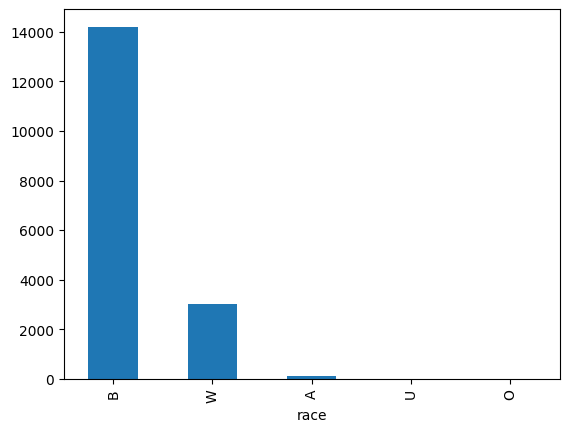

In [34]:
shoot_df['race'].value_counts().plot(kind='bar')
plt.show()

In [32]:
shoot_df['sex'].value_counts()

sex
M    15608
F     1882
Name: count, dtype: int64

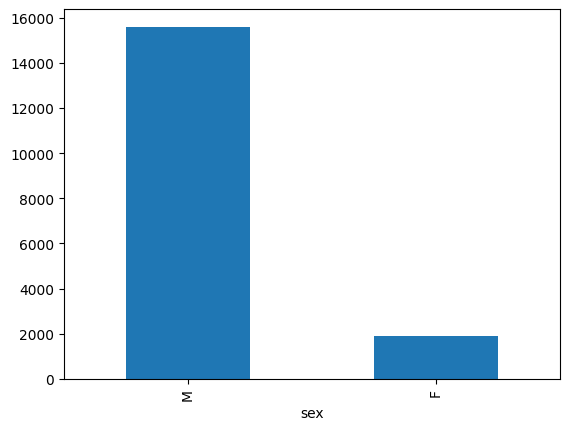

In [9]:
shoot_df['sex'].value_counts().plot(kind='bar')
plt.show()

In [10]:
shoot_df['age'].value_counts()

age
21.0     824
20.0     808
23.0     780
22.0     773
19.0     758
        ... 
88.0       1
81.0       1
84.0       1
117.0      1
87.0       1
Name: count, Length: 89, dtype: int64

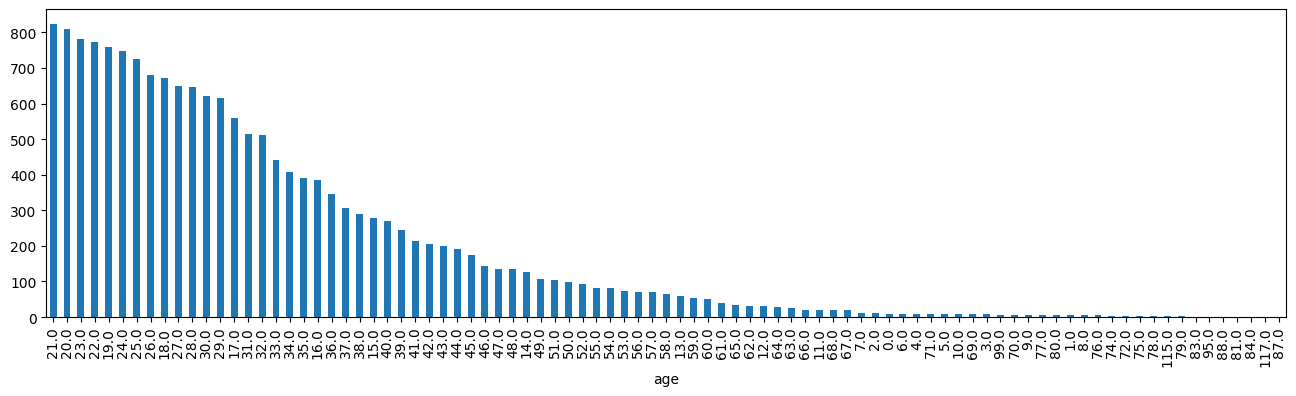

In [36]:
shoot_df['age'].value_counts().plot(kind='bar', figsize=(16,4))
plt.show()

I then combined these variables to analyze the data at the demographic level, grouping individuals by race, sex, and age.

In [13]:
bins=[0,9,19,29,39,49,59,69,79,100]
labels=["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69","70-79", "80+"]

shoot_df['age_group'] = pd.cut(shoot_df['age'], bins=bins, labels=labels)

In [14]:
shoot_df['demographic'] = shoot_df['race_long'] + ' ' + shoot_df['sex'] + ' ' + shoot_df['age_group'].astype(str)

In [39]:
shoot_df['demographic'].value_counts().head(5)

demographic
Black M 20-29    5516
Black M 30-39    2920
Black M 10-19    2267
Black M 40-49    1217
White M 20-29    1010
Name: count, dtype: int64

The data shows a clear concentration of shootings among young men, particularly Black men between the ages of 20–29, who make up the largest share by a significant margin. This group far exceeds any other demographic, with counts nearly double the next highest category. More broadly, the top categories are dominated by Black males across adjacent age groups, especially from 10–39, highlighting a strong age and gender skew in the distribution of shootings.

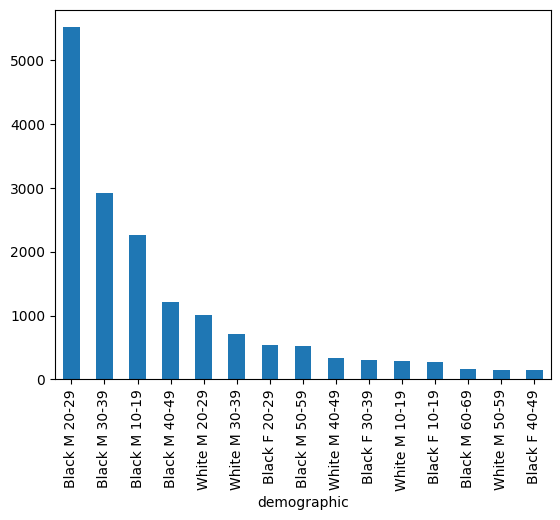

In [16]:
shoot_df['demographic'].value_counts().head(15).plot(kind='bar')
plt.show()

To ensure no groups were overlooked, I examined the full distribution across all demographic categories. This revealed a highly uneven pattern, with many groups appearing only rarely while a small number account for the majority of cases.

In [17]:
shoot_df.groupby('demographic').size()

demographic
Asian F 10-19       2
Asian F 20-29       8
Asian F 30-39       2
Asian F 40-49       4
Asian F 50-59       5
Asian F 60-69       1
Asian M 10-19       9
Asian M 20-29      26
Asian M 30-39      26
Asian M 40-49      19
Asian M 50-59      11
Asian M 60-69       6
Asian M 70-79       1
Black F 0-9        19
Black F 10-19     278
Black F 20-29     541
Black F 30-39     302
Black F 40-49     147
Black F 50-59      83
Black F 60-69      42
Black F 70-79       6
Black F 80+         3
Black M 0-9        44
Black M 10-19    2267
Black M 20-29    5516
Black M 30-39    2920
Black M 40-49    1217
Black M 50-59     515
Black M 60-69     163
Black M 70-79      26
Black M 80+         9
Other M 20-29       1
White F 0-9         8
White F 10-19      47
White F 20-29     144
White F 30-39     117
White F 40-49      55
White F 50-59      28
White F 60-69      11
White F 70-79       7
White F 80+         3
White M 0-9         5
White M 10-19     291
White M 20-29    1010
White M 30-39     70

In [20]:
demo_counts = shoot_df.groupby('demographic').size()
demo_counts = demo_counts[demo_counts > 50]

demo_stats = demo_stats.loc[demo_counts.index]

Lastly, I looked at trends over the past decade. Based on earlier research showing a spike during the pandemic, I focused on that period to see whether the demographics of those affected changed, or remained consistent.

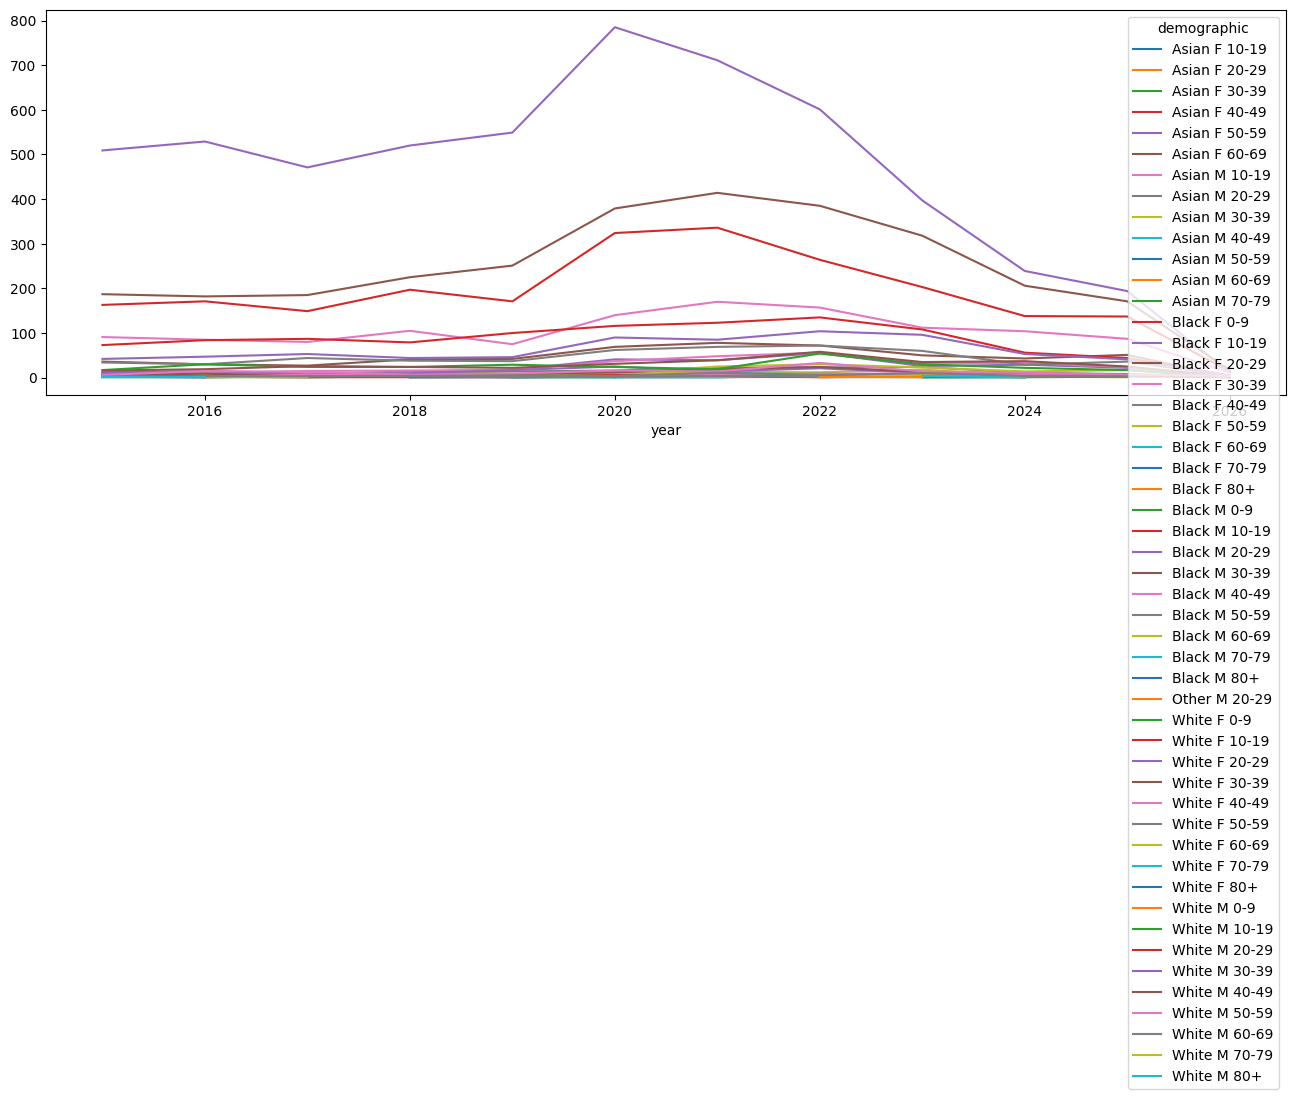

In [21]:
shoot_df.groupby(['year','demographic']).size().unstack().plot(figsize=(16,5))
plt.show()

The plots above were too crowded to interpret clearly, so I adjusted the graph to show only the top five demographic groups. I also included the group with the fewest shootings, though it remains difficult to distinguish due to its low counts.

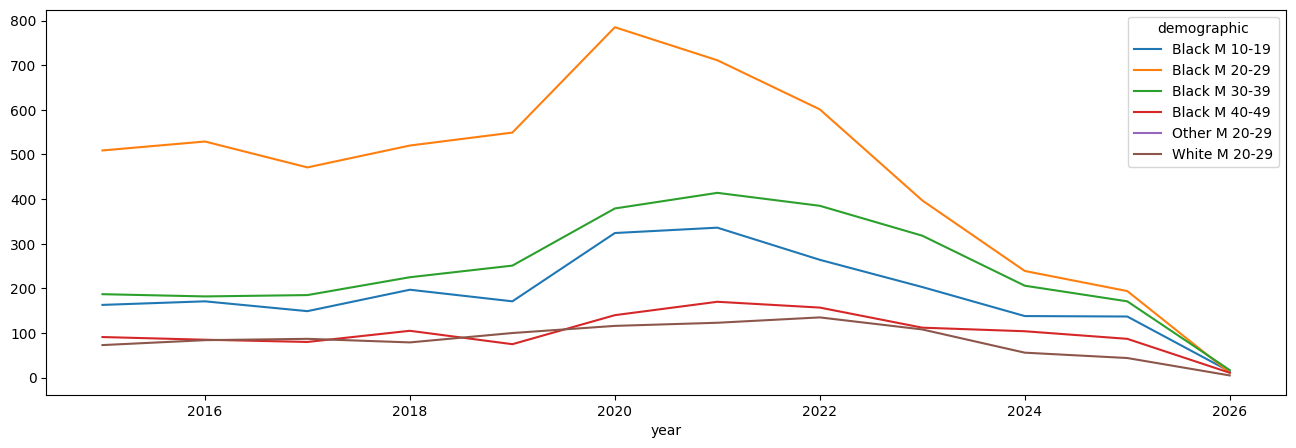

In [29]:
plot_df = filtered_df.groupby(['year','demographic']).size().unstack()

ax = plot_df.plot(figsize=(16,5))

for line in ax.get_lines():
    if line.get_label() in lowest:
        line.set_linestyle('--')
        line.set_linewidth(3)

plt.show()

Overall, the results show that while shootings increased across most demographics during the pandemic, the highest number of cases consistently involved Black males aged 20–29. Importantly, this pattern remained stable even during periods of heightened violence.

It is also important to consider the broader context: Philadelphia’s Black population makes up roughly 40% of the total population. As a result, these findings may not be directly comparable to cities with different demographic compositions, and the distribution observed here may partly reflect the city’s underlying population structure.

![](data/retry.png)